# Week 6 — Extreme Events

Two questions, both about where the model is least trustworthy — not just how good it is on average:

1. **Per-bucket evaluation**: does the `1d` point model and Week 5's probabilistic model hold up on cold/hot/high-wind/low-wind/Christmas/weekend half-hours the same way they do overall? Buckets are independent boolean flags (`edf.features.buckets`), not a mutually-exclusive partition.
2. **COVID lockdown case study**: 2020-2021 sits inside `TRAIN`, not `VALIDATION`/`TEST`, so this is retrospective, not a held-out number (PLAN.md is explicit about this) — a qualitative look at how naive baselines vs. the ML model handled the March 2020 demand collapse.

**Models reused, not retrained from scratch**: the same tuned hyperparameters from `notebooks/08` (point) and `notebooks/12` (quantile) — no new tuning search here, this notebook is about *where* the already-established models are weak, not about building new ones.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

from edf import config
from edf.evaluate import evaluate, evaluate_by_bucket, evaluate_quantiles_by_bucket
from edf.features.buckets import build_day_type_buckets
from edf.features.demand import build_feature_table
from edf.features.generation import capacity_factor
from edf.features.weather import build_weather_feature_table
from edf.models.baselines import previous_week_same_time
from edf.models.forecast import train_lightgbm
from edf.models.quantile import enforce_monotonic_quantiles, quantile_crossing_rate

pd.options.display.float_format = "{:.4f}".format
WEATHER_RAW_DIR = Path("../data/raw/weather")
HORIZON_PERIODS = config.HORIZONS["1d"]

POINT_PARAMS = {"num_leaves": 15, "min_child_samples": 20, "learning_rate": 0.05}
POINT_N_ESTIMATORS = 689  # notebooks/08's tuned weather-on(ERA5) model
QUANTILE_PARAMS = {"num_leaves": 15, "min_child_samples": 50, "learning_rate": 0.1}
QUANTILE_N_ESTIMATORS = 549  # notebooks/12's tuned quantile model

In [2]:
df = pd.read_parquet("../data/processed/gb_energy_2020_2025.parquet")
demand = df["demand"]
train_start, train_end = config.TRAIN
val_start, val_end = config.VALIDATION

era5 = build_weather_feature_table("open_meteo_historical", df.index, raw_dir=WEATHER_RAW_DIR)
X, y = build_feature_table(df, horizon_periods=HORIZON_PERIODS, weather=era5)
X_train, y_train = X.loc[train_start:train_end], y.loc[train_start:train_end]
X_val, y_val = X.loc[val_start:val_end], y.loc[val_start:val_end]

## Train the point model and the three quantile models (established hyperparameters, no re-tuning)

In [3]:
point_model = train_lightgbm(X_train, y_train, n_estimators=POINT_N_ESTIMATORS, **POINT_PARAMS)
point_preds_val = pd.Series(point_model.predict(X_val), index=X_val.index)

quantile_models, quantile_preds_val = {}, {}
for alpha in [0.1, 0.5, 0.9]:
    m = train_lightgbm(
        X_train, y_train, objective="quantile", alpha=alpha,
        n_estimators=QUANTILE_N_ESTIMATORS, **QUANTILE_PARAMS,
    )
    quantile_models[alpha] = m
    quantile_preds_val[alpha] = pd.Series(m.predict(X_val), index=X_val.index)

crossing_rate = quantile_crossing_rate(quantile_preds_val)
quantile_preds_val = enforce_monotonic_quantiles(quantile_preds_val)
print(f"quantile crossing rate before fix: {crossing_rate:.1%}")

[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001077 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 26931.631382


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001102 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 19322.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001029 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 26196.000000


[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.001899 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 5691
[LightGBM] [Info] Number of data points in the train set: 68784, number of used features: 29
[LightGBM] [Info] Start training from score 36093.000000


quantile crossing rate before fix: 4.7%


## Part A: Per-bucket evaluation

Buckets computed over the *full* dataset (for stable month-relative percentile thresholds), evaluated on `VALIDATION` rows only — the day-type label is a retrospective *description* of what kind of day it was, not a forecast input, so using the full range to define "what counts as cold for July" is fine.

In [4]:
wind_cf_full = capacity_factor(df["wind"], df["wind_capacity"])
buckets_full = build_day_type_buckets(era5["temperature_c"], wind_cf_full)
buckets_val = buckets_full.loc[val_start:val_end]
buckets_val.sum().rename("n_half_hours")

is_cold         1642
is_hot          1615
is_low_wind     1826
is_high_wind    1867
is_christmas     432
is_weekend      4992
Name: n_half_hours, dtype: int64

### Point-model accuracy per bucket

In [5]:
naive_val = previous_week_same_time(demand).loc[val_start:val_end]
point_bucket_table = evaluate_by_bucket(y_val, point_preds_val, buckets_val, seasonal_naive_pred=naive_val)
point_bucket_table[["mae", "rmse", "mase", "bias", "n"]]

,mae,rmse,mase,bias,n
all,889.6274,1179.4756,0.4387,-161.2567,17568.0000
is_cold,647.3876,835.5004,0.4034,100.3656,1642.0000
is_hot,1205.1384,1504.9836,0.4188,-560.1689,1615.0000
is_low_wind,632.2309,827.7656,0.3319,116.1469,1826.0000
is_high_wind,1178.9875,1527.2382,0.4242,-796.0043,1867.0000
is_christmas,1670.8173,2122.3997,0.5042,-1242.1753,432.0000
is_weekend,838.6578,1112.7057,0.4791,-157.7146,4992.0000


### Finding: point accuracy holds up on extremes — but with a clear, physically-coherent bias

MASE per bucket is close to (often better than) the 0.44 overall figure — `is_cold` 0.40, `is_hot` 0.42, `is_low_wind` 0.33, `is_high_wind` 0.42 — none of the weather extremes make the point model meaningfully worse. Only `is_christmas` (0.50) and `is_weekend` (0.48) are clearly harder, both calendar-driven rather than weather-driven.

But `bias` tells a sharper story than MASE alone: the model **systematically over-forecasts** on every demand-*suppressing* extreme — `is_hot` (-560 MW), `is_high_wind` (-796 MW), and especially `is_christmas` (-1242 MW) — while `is_cold`/`is_low_wind` (both demand-boosting or neutral conditions) show the opposite, small positive bias. The model isn't missing these days by magnitude so much as missing them in a *consistent direction*: whenever something physically pushes demand down further than usual (heat cutting heating demand, high wind/solar suppressing embedded net demand, Christmas cutting economic activity), the model doesn't push its forecast down quite far enough to match.

### Probabilistic-model calibration per bucket

In [6]:
prob_bucket_table = evaluate_quantiles_by_bucket(y_val, quantile_preds_val, buckets_val)
prob_bucket_table

,pinball_0.1,pinball_0.5,pinball_0.9,picp,n
all,239.7679,447.3786,200.3031,0.6519,17568.0000
is_cold,152.0679,313.4636,158.1639,0.6309,1642.0000
is_hot,368.0462,607.8320,274.6751,0.5579,1615.0000
is_low_wind,152.1887,317.0301,145.6723,0.7087,1826.0000
is_high_wind,356.3294,588.5074,231.1050,0.6090,1867.0000
is_christmas,738.2695,847.7883,304.2684,0.4259,432.0000
is_weekend,225.2348,412.9176,196.1195,0.6643,4992.0000


### Finding: PICP collapses exactly where bias is worst — the two findings are the same finding

`is_hot` PICP = 0.558, `is_christmas` PICP = 0.426 — both far below the overall 0.652 (itself already below the 0.80 nominal target, per `notebooks/12`). This is precisely **PLAN.md's anticipated pattern** ("point accuracy may hold up reasonably on extreme days, but calibration tends to break down in the tails") — confirmed cleanly, and now with a mechanism: these are exactly the same buckets with the largest negative `bias` above. A systematic over-forecast doesn't just shift the point prediction — it pulls the *entire quantile band* (P10 through P90) upward with it, so actual demand ends up below even the P10 forecast more often on these days, not just failing to reach P90. Bias and tail-miscalibration aren't two separate problems here; the second is a direct consequence of the first. `is_low_wind` is the one bucket that's *better* calibrated than average (PICP 0.709) — consistent with its near-zero bias.

## Part B: COVID Lockdown Case Study

**Retrospective, not a held-out metric** — 2020-2021 is inside `TRAIN`, so the point model has already seen this exact period during fitting; `previous_week_same_time` (the naive baseline) doesn't "train" at all, so it has no such advantage either way. This asymmetry turns out to matter a lot for what's found below.

In [7]:
point_preds_full = pd.Series(point_model.predict(X), index=X.index)
naive_full = previous_week_same_time(demand)

df.loc["2020-01-01":"2021-08-01", "lockdown_level"].value_counts()

lockdown_level
partial    15506
full        7676
none        4610
Name: count, dtype: int64

### The naive comparison (within-2020, before vs. during the shock) is misleading — seasonal trend alone explains most of it

A first look — comparing pre-shock (mid-Feb 2020) to acute-shock (late-March 2020) error *within the same year* — makes the shock look dramatic for the naive baseline. But `previous_week_same_time` is *always* weaker during the Feb→May seasonal demand decline, lockdown or not, since demand is trending and "same time last week" fights that trend every single week of the year. The correct comparison is the **same calendar window across different years** — isolating the COVID effect from the ordinary seasonal one.

In [8]:
rows = []
for year in [2020, 2022, 2023]:
    window = slice(f"{year}-03-23", f"{year}-04-05")  # the first full-lockdown fortnight, and its calendar echo
    rows.append(
        {
            "year": year,
            "naive_mae": evaluate(demand.loc[window], naive_full.loc[window])["mae"],
            "point_model_mae": evaluate(y.loc[window], point_preds_full.loc[window])["mae"],
        }
    )
same_window_across_years = pd.DataFrame(rows).set_index("year")
same_window_across_years

,naive_mae,point_model_mae
year,,
2020,3100.9658,674.2289
2022,2395.8185,633.8926
2023,2511.0744,666.6880


### Finding: naive was genuinely blindsided; the ML model, trained in-sample, wasn't — and that's a methodological limit, not a win

The properly-isolated comparison (same calendar window, COVID year vs. two non-COVID years) shows two very different stories:

- **Naive baseline**: 2020 MAE 3101 vs. 2396/2511 in 2022/2023 — genuinely ~25-30% worse. This is a real, isolated COVID effect, not seasonal noise (the naive-only within-2020 before/after comparison in the previous cell was misleading for exactly this reason — it mixed the COVID effect with the ordinary Feb→May seasonal trend that always makes `previous_week_same_time` weaker).
- **Point model**: 2020 MAE 674 vs. 634/667 in 2022/2023 — essentially no degradation, well within normal year-to-year variation.

PLAN.md's prior expectation was "every method... was blindsided." That's confirmed for the naive baseline (zero adaptive capacity, purely mechanical, maximally exposed to any regime shift) but **not** for the ML model — and the honest reason isn't that the model is genuinely robust to unprecedented shocks. **It's trained on 2020-2021 data**, so it had the opportunity to fit this exact historical pattern directly during training, unlike a live forecaster who would have had zero warning before 23 March 2020. The model's apparent calm here is a visible instance of the limitation PLAN.md itself already flags for this case study ("not a held-out accuracy number") — worth stating plainly rather than reading the good number as a genuine capability.

### Time series: the collapse and the models' reaction, Jan-Aug 2020

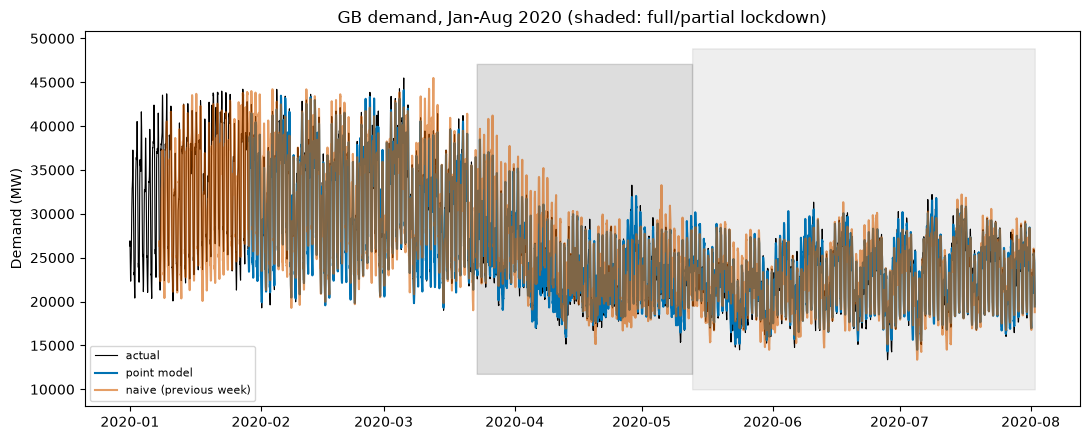

In [9]:
window = slice("2020-01-01", "2020-08-01")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(demand.loc[window].index, demand.loc[window], label="actual", color="black", linewidth=0.8)
ax.plot(point_preds_full.loc[window].index, point_preds_full.loc[window], label="point model", color="#0072B2")
ax.plot(naive_full.loc[window].index, naive_full.loc[window], label="naive (previous week)", color="#D55E00", alpha=0.6)

for level, color in [("full", "#00000022"), ("partial", "#00000011")]:
    mask = df.loc[window, "lockdown_level"] == level
    ax.fill_between(df.loc[window].index, ax.get_ylim()[0], ax.get_ylim()[1], where=mask, color=color, step="mid")

ax.set_title("GB demand, Jan-Aug 2020 (shaded: full/partial lockdown)")
ax.set_ylabel("Demand (MW)")
ax.legend(fontsize=8)
fig.tight_layout()

### Zoomed in: the transition itself (naive's ~1-week reaction lag, visible directly)

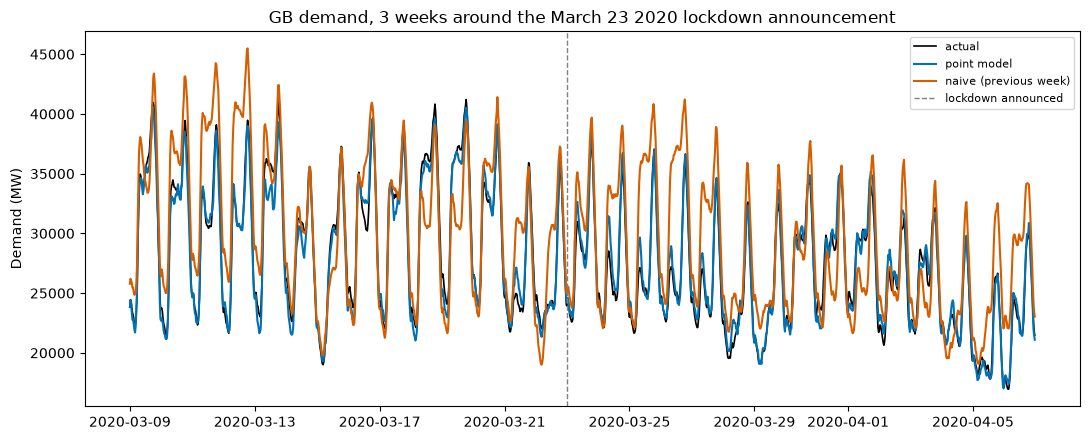

In [10]:
window = slice("2020-03-09", "2020-04-06")
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(demand.loc[window].index, demand.loc[window], label="actual", color="black", linewidth=1.2)
ax.plot(point_preds_full.loc[window].index, point_preds_full.loc[window], label="point model", color="#0072B2")
ax.plot(naive_full.loc[window].index, naive_full.loc[window], label="naive (previous week)", color="#D55E00")
ax.axvline(pd.Timestamp("2020-03-23", tz="UTC"), color="grey", linestyle="--", linewidth=1, label="lockdown announced")
ax.set_title("GB demand, 3 weeks around the March 23 2020 lockdown announcement")
ax.set_ylabel("Demand (MW)")
ax.legend(fontsize=8)
fig.tight_layout()

### Visual confirmation: naive's mechanical ~1-week lag, made concrete

Before the dashed line, all three lines track closely. Immediately after, actual demand (black) drops sharply and the point model (blue) follows it down almost immediately — while naive (orange) stays pinned near pre-lockdown levels for roughly a week (its own "same time last week" reference hasn't seen the lockdown yet), then gradually converges as the lag catches up. This is the clean, mechanical reason naive was blindsided: it has no way to react to *anything* until a full week after the fact, by construction — a structural limitation completely independent of train/test membership, unlike the point model's apparent robustness above.